<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



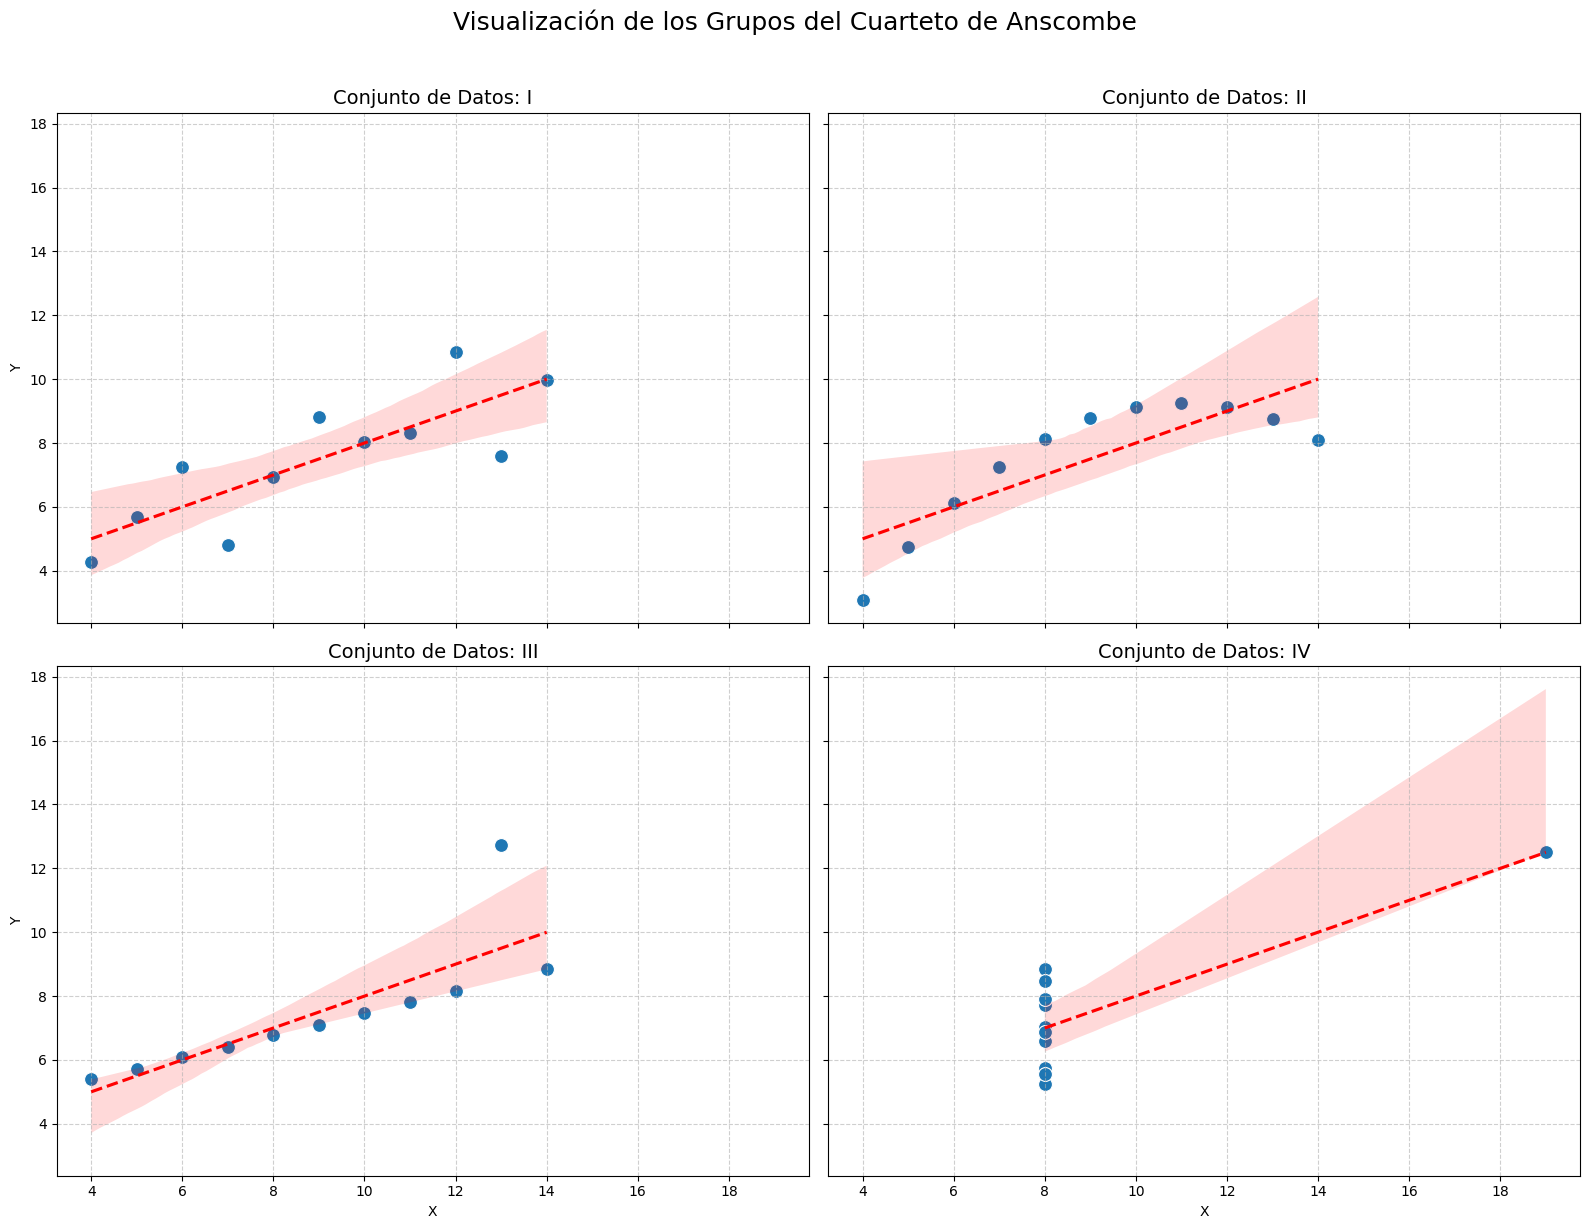

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos si no están cargados
data = sns.load_dataset('anscombe')

# Configurar la figura
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Crear gráficos de dispersión por grupo
for i, dataset_name in enumerate(data['dataset'].unique()):
    subset = data[data['dataset'] == dataset_name]
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100)
    # Línea de tendencia visual
    sns.regplot(x='x', y='y', data=subset, ax=axes[i], scatter=False, color='red', line_kws={'linestyle':'--'})
    axes[i].set_title(f'Conjunto de Datos: {dataset_name}', fontsize=14)
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Visualización de los Grupos del Cuarteto de Anscombe', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

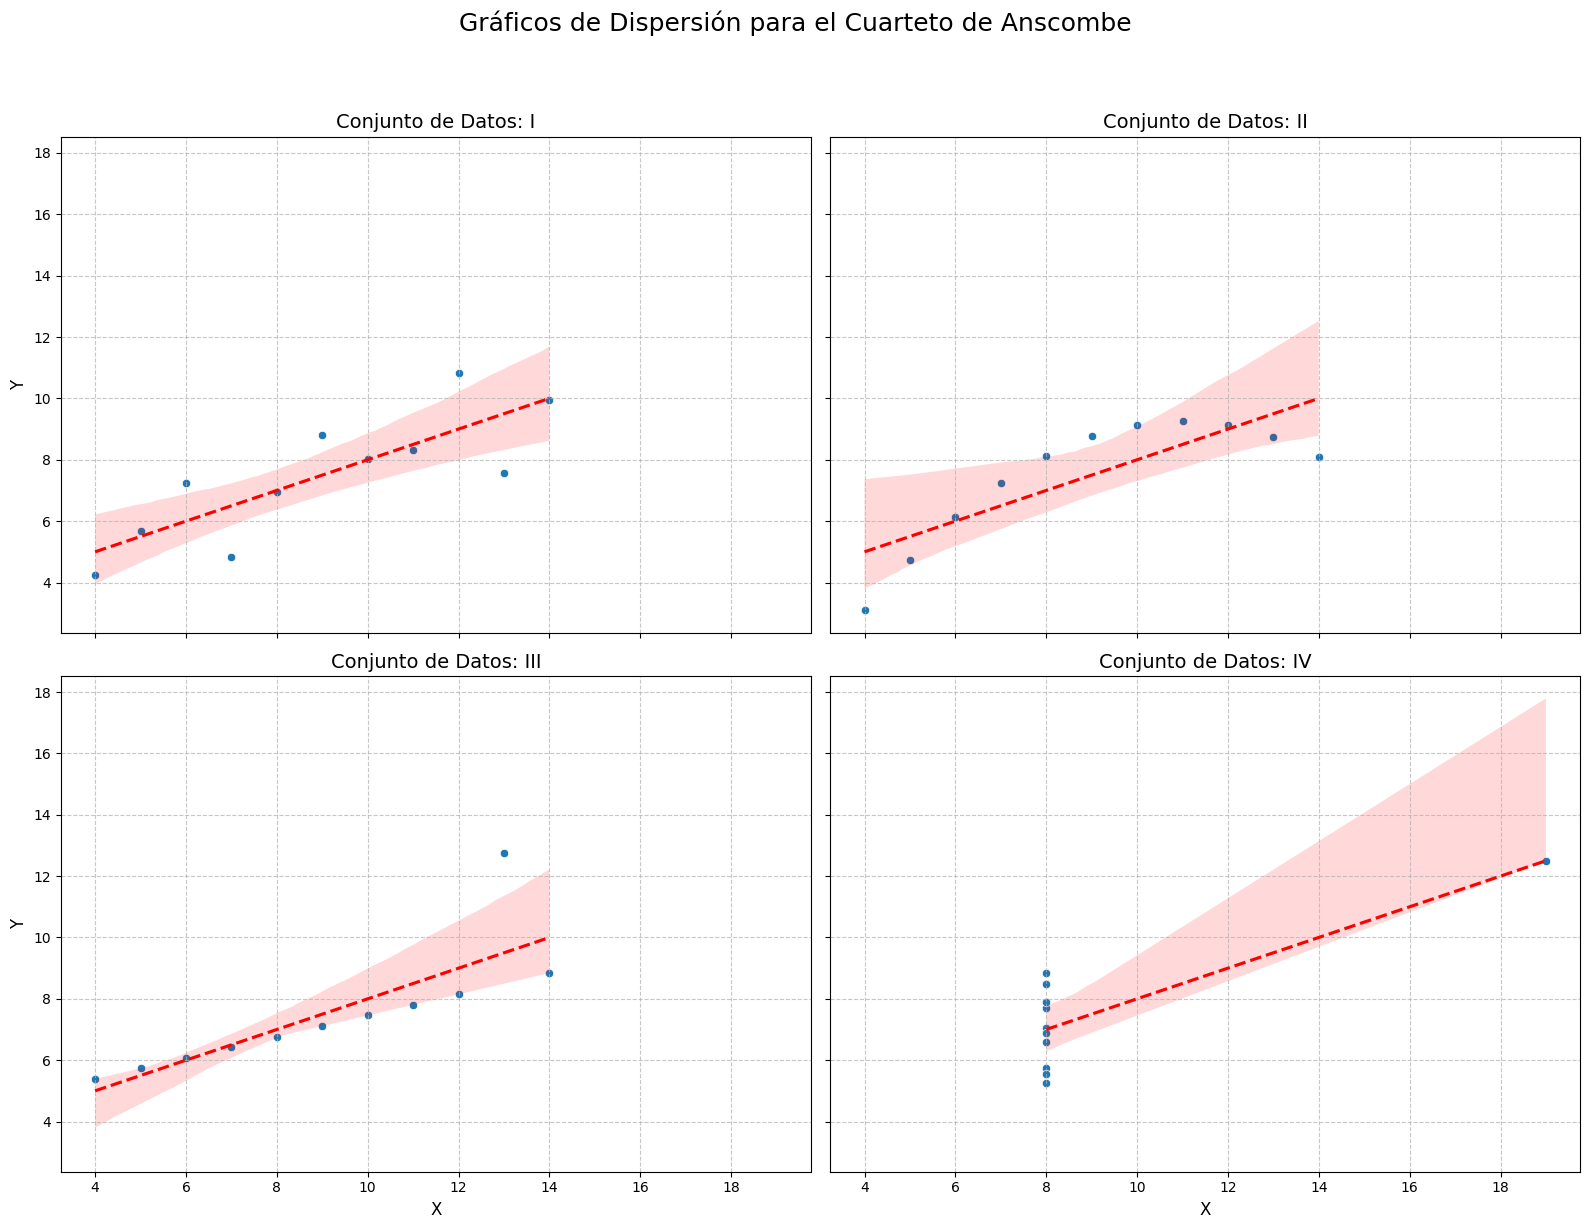

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("anscombe")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, dataset_name in enumerate(data['dataset'].unique()):
    subset = data[data['dataset'] == dataset_name]
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i])
    sns.regplot(x='x', y='y', data=subset, ax=axes[i], scatter=False, color='red', line_kws={'linestyle':'--'})
    axes[i].set_title(f'Conjunto de Datos: {dataset_name}', fontsize=14)
    axes[i].set_xlabel('X', fontsize=12)
    axes[i].set_ylabel('Y', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Gráficos de Dispersión para el Cuarteto de Anscombe', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Análisis de los Gráficos de Dispersión:

Observando los gráficos de dispersión generados para cada conjunto de datos del cuarteto de Anscombe, se pueden identificar las siguientes diferencias significativas y características particulares:

*   **Conjunto I (Superior Izquierda):** Este gráfico muestra una clara relación lineal positiva. Los puntos están distribuidos de manera uniforme alrededor de una línea recta, lo que sugiere que un modelo de regresión lineal sería apropiado para este conjunto de datos.

*   **Conjunto II (Superior Derecha):** Aquí, la relación entre `x` y `y` es claramente no lineal, exhibiendo una forma parabólica o curvilínea. Aunque hay una tendencia general de aumento, la forma no es recta, lo que indica que un modelo lineal simple no capturaría adecuadamente la relación subyacente. La línea de regresión lineal (punteada en rojo) muestra una tendencia general, pero no se ajusta bien a la curva de los puntos.

*   **Conjunto III (Inferior Izquierda):** Este conjunto también presenta una relación predominantemente lineal. Sin embargo, hay un `outlier` prominente en la parte superior derecha que tira de la línea de regresión hacia arriba. Si se ignorara este punto, la relación lineal sería más fuerte y con una pendiente diferente. La presencia de este valor atípico distorsiona la percepción de la relación lineal.

*   **Conjunto IV (Inferior Derecha):** Este gráfico es muy distinto. La mayoría de los puntos de datos tienen el mismo valor de `x` (alrededor de 8), y solo hay un punto con un valor de `x` muy diferente (alrededor de 19). Este único punto atípico ejerce una influencia enorme en la línea de regresión lineal, forzándola a tener una pendiente. Sin ese punto, no habría una relación lineal discernible, ya que todos los demás puntos formarían una línea vertical. La línea de regresión lineal parece tener una pendiente positiva, pero es casi enteramente dictada por el único punto alejado.

Estas visualizaciones son cruciales porque, como veremos en los siguientes pasos, las estadísticas descriptivas para todos estos conjuntos serán muy similares, pero sus patrones subyacentes son fundamentalmente diferentes. Esto subraya la importancia de la visualización de datos antes de cualquier análisis estadístico o modelado.

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [10]:
# Generar resumen estadístico descriptivo
print('Resumen Estadístico del Cuarteto de Anscombe por Grupo:\n')
resumen = data.groupby('dataset').describe()

# Mostrar estadísticas clave de forma legible
for grupo in data['dataset'].unique():
    print(f'--- Grupo {grupo} ---')
    print(data[data['dataset'] == grupo][['x', 'y']].describe())
    print('\n')

Resumen Estadístico del Cuarteto de Anscombe por Grupo:

--- Grupo I ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031568
min     4.000000   4.260000
25%     6.500000   6.315000
50%     9.000000   7.580000
75%    11.500000   8.570000
max    14.000000  10.840000


--- Grupo II ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031657
min     4.000000   3.100000
25%     6.500000   6.695000
50%     9.000000   8.140000
75%    11.500000   8.950000
max    14.000000   9.260000


--- Grupo III ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500000
std     3.316625   2.030424
min     4.000000   5.390000
25%     6.500000   6.250000
50%     9.000000   7.110000
75%    11.500000   7.980000
max    14.000000  12.740000


--- Grupo IV ---
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.030579
m

Regresión Lineal para el Cuarteto de Anscombe:

----- Conjunto de Datos: I -----
Coeficiente (pendiente): 0.500
Intercepción: 3.000
Error Cuadrático Medio (MSE): 1.251
Coeficiente de Determinación (R²): 0.667


----- Conjunto de Datos: II -----
Coeficiente (pendiente): 0.500
Intercepción: 3.001
Error Cuadrático Medio (MSE): 1.252
Coeficiente de Determinación (R²): 0.666


----- Conjunto de Datos: III -----
Coeficiente (pendiente): 0.500
Intercepción: 3.002
Error Cuadrático Medio (MSE): 1.251
Coeficiente de Determinación (R²): 0.666


----- Conjunto de Datos: IV -----
Coeficiente (pendiente): 0.500
Intercepción: 3.002
Error Cuadrático Medio (MSE): 1.249
Coeficiente de Determinación (R²): 0.667




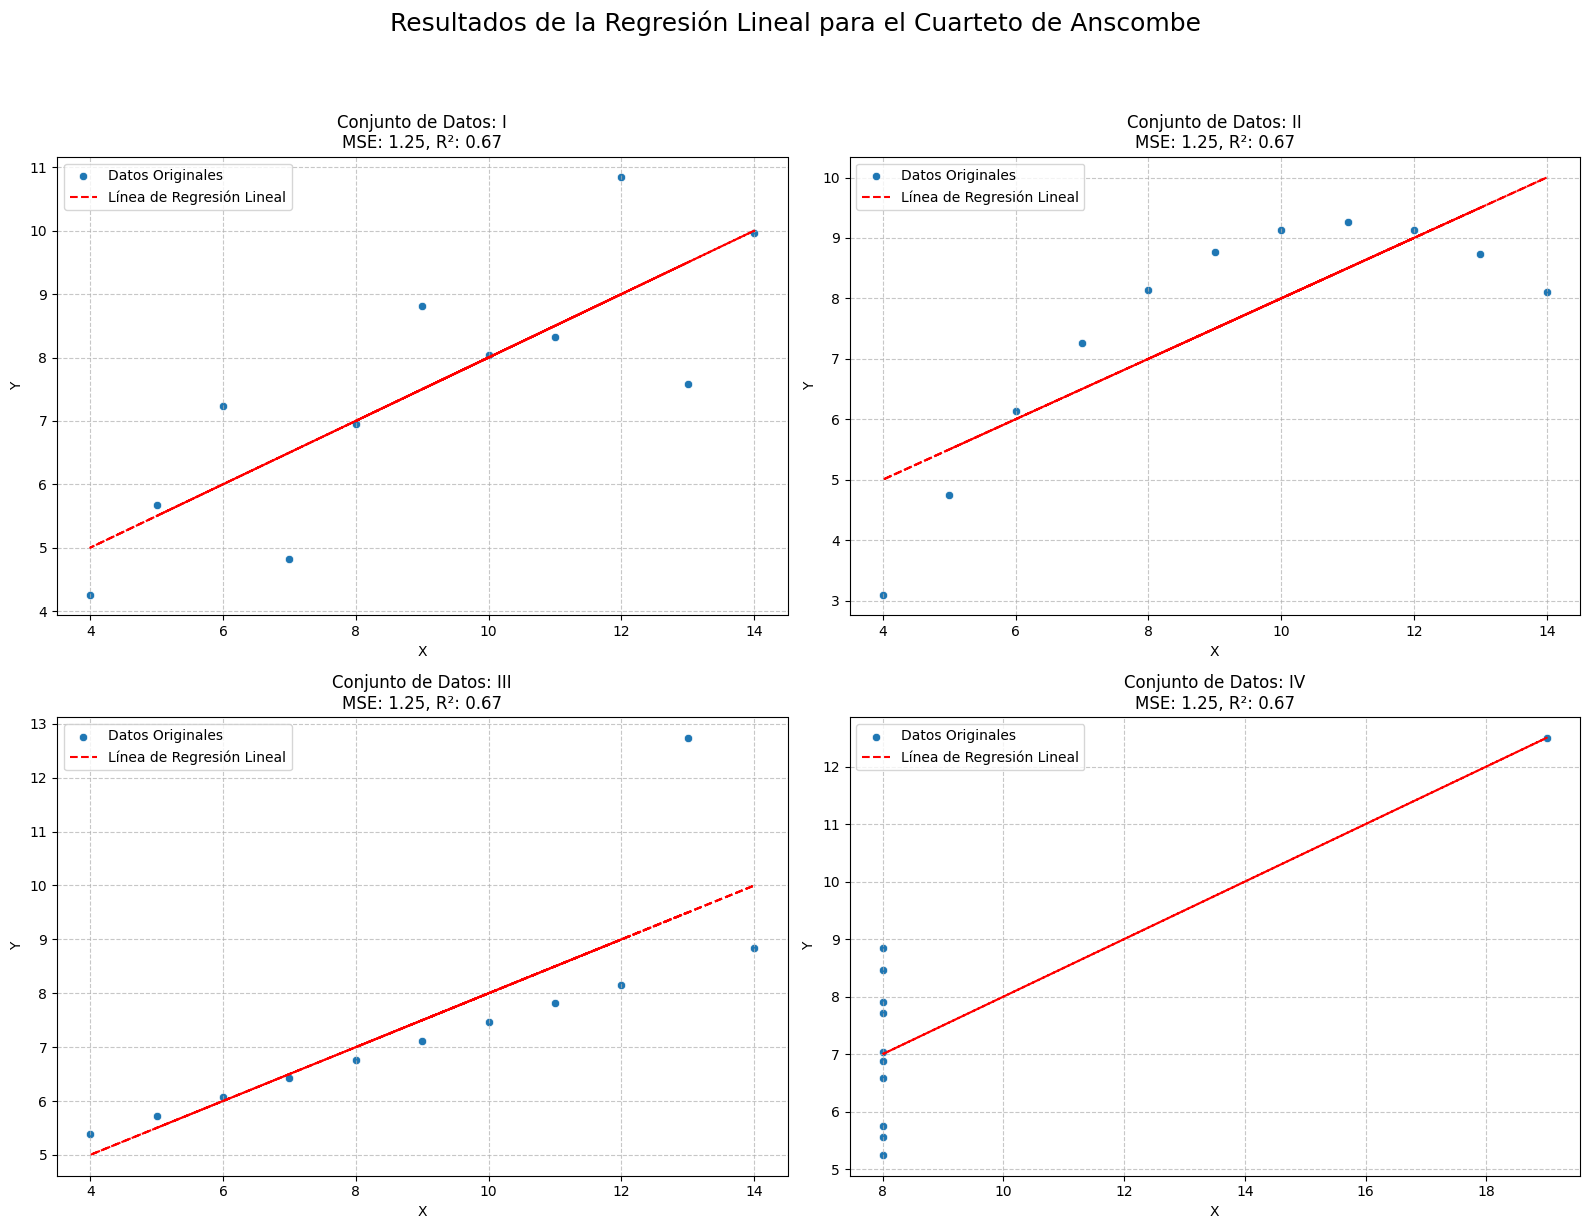

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print('Regresión Lineal para el Cuarteto de Anscombe:\n')

plt.figure(figsize=(16, 12))

for i, dataset_name in enumerate(data['dataset'].unique()):
    subset = data[data['dataset'] == dataset_name]

    X = subset[['x']]
    y = subset['y']

    # Crear y entrenar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)

    # Realizar predicciones
    y_pred = model.predict(X)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Imprimir resultados
    print(f'----- Conjunto de Datos: {dataset_name} -----')
    print(f'Coeficiente (pendiente): {model.coef_[0]:.3f}')
    print(f'Intercepción: {model.intercept_:.3f}')
    print(f'Error Cuadrático Medio (MSE): {mse:.3f}')
    print(f'Coeficiente de Determinación (R²): {r2:.3f}')
    print('\n')

    # Graficar los resultados de la regresión
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x='x', y='y', data=subset, label='Datos Originales')
    plt.plot(X, y_pred, color='red', linestyle='--', label='Línea de Regresión Lineal')
    plt.title(f'Conjunto de Datos: {dataset_name}\nMSE: {mse:.2f}, R²: {r2:.2f}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

plt.suptitle('Resultados de la Regresión Lineal para el Cuarteto de Anscombe', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Análisis de los Resultados de la Regresión Lineal:

Los resultados de ajustar un modelo de regresión lineal a cada conjunto de datos del cuarteto de Anscombe confirman la advertencia del cuarteto: las métricas estadísticas por sí solas pueden ser engañosas sin la visualización.

Observamos las siguientes características:

*   **Estadísticas de Regresión Comunes:** Para todos los conjuntos (I, II, III, IV), la regresión lineal produce coeficientes (pendientes) y valores de intercepción sorprendentemente similares. Esto se traduce en un **Error Cuadrático Medio (MSE)** y un **Coeficiente de Determinación (R²)** que también son muy cercanos entre sí para todos los grupos. Esto es precisamente lo que hace al Cuarteto de Anscombe un ejemplo tan poderoso: estadísticamente, un modelo lineal parece ajustarse 'igualmente bien' a todos ellos.

*   **Conjunto I (Relación Lineal Pura):**
    *   **MSE y R²:** Los valores indican un ajuste lineal muy bueno, lo cual es coherente con la visualización. La línea de regresión sigue de cerca la tendencia de los puntos.
    *   **Interpretación:** La regresión lineal es un modelo muy apropiado para este tipo de datos, capturando eficazmente la relación subyacente.

*   **Conjunto II (Relación No Lineal):**
    *   **MSE y R²:** A pesar de los valores estadísticamente 'buenos' de MSE y R², el gráfico de dispersión revela claramente que la relación es curvilínea. La línea de regresión lineal no captura la curvatura de los datos, subestimando en los extremos y sobrestimando en el centro (o viceversa).
    *   **Interpretación:** El modelo lineal es inadecuado. Aunque las métricas no lo gritan, la visualización nos muestra que el modelo es una simplificación excesiva que no representa la verdadera relación.

*   **Conjunto III (Outlier Influyente):**
    *   **MSE y R²:** Similar al Conjunto I en sus métricas, pero el gráfico muestra que un único punto atípico ejerce una influencia desproporcionada en la pendiente y la intercepción de la línea de regresión. Este `outlier` 'tira' de la línea de regresión, distorsionando la percepción de la relación lineal para la mayoría de los puntos.
    *   **Interpretación:** El modelo lineal es sensible a los `outliers`. La línea de regresión podría ser una representación engañosa de la relación entre la mayoría de los puntos si no se considera el impacto del valor atípico.

*   **Conjunto IV (Outlier de Alto Apalancamiento):**
    *   **MSE y R²:** De nuevo, las métricas son similares. Sin embargo, en este caso, casi todos los puntos tienen el mismo valor de `x`, y la pendiente de la línea de regresión está casi enteramente determinada por un único punto con un valor de `x` muy diferente (alto apalancamiento). Sin ese punto, la regresión lineal sería casi una línea vertical o indefinida.
    *   **Interpretación:** Este es un caso extremo donde un único punto domina completamente el ajuste del modelo lineal. El modelo es extremadamente frágil y su 'buen' ajuste es una ilusión creada por un solo dato, no por una tendencia general en la mayoría de los puntos.

**Conclusión:**

Este análisis resalta la **importancia crítica de la visualización de datos** antes y durante el análisis estadístico o el modelado predictivo. Confiar únicamente en métricas estadísticas como MSE y R² para evaluar un modelo puede llevar a conclusiones erróneas sobre la idoneidad del modelo y la naturaleza de las relaciones en los datos. Los modelos pueden tener un 'buen' desempeño numérico en diferentes conjuntos de datos por razones muy diferentes, y solo la inspección visual revela estas verdaderas diferencias.

### Estrategias para Mejorar el Ajuste del Modelo:

Como hemos observado, la regresión lineal no es adecuada para todos los conjuntos del Cuarteto de Anscombe. A continuación, se proponen estrategias para mejorar el ajuste para los grupos problemáticos:

*   **Conjunto I:** El ajuste lineal es apropiado, no se requiere ninguna estrategia adicional.

*   **Conjunto II (Relación No Lineal):** Para datos con una relación curvilínea, un modelo de regresión lineal es insuficiente. La estrategia aquí es utilizar un **modelo de regresión polinómica**. Al introducir términos de orden superior (por ejemplo, $x^2$), podemos capturar la curvatura en los datos y lograr un mejor ajuste.

*   **Conjunto III (Outlier Influyente):** Este conjunto tiene un `outlier` que "tira" de la línea de regresión, sesgando el modelo. La estrategia consiste en **identificar y eliminar este punto atípico** para luego reajustar el modelo de regresión lineal a los datos restantes. Esto permitirá que el modelo lineal represente mejor la tendencia de la mayoría de los puntos.

*   **Conjunto IV (Outlier de Alto Apalancamiento):** Similar al Conjunto III, este conjunto tiene un punto de alto apalancamiento que domina la determinación de la línea de regresión. La estrategia es **eliminar este punto influyente** y luego reevaluar el ajuste lineal. Al hacer esto, esperamos ver que la relación lineal entre los puntos restantes es mínima o inexistente, lo que subraya la fragilidad del modelo lineal cuando un solo punto tiene tanta influencia.

Modelos Mejorados y Alternativos para el Cuarteto de Anscombe:

----- Conjunto de Datos: I (Linear) -----
Coeficiente (pendiente): 0.500
Intercepción: 3.000
Error Cuadrático Medio (MSE): 1.251
Coeficiente de Determinación (R²): 0.667


----- Conjunto de Datos: II (Polynomial) -----
Coeficientes (Polinómico): [ 0.          2.78083916 -0.12671329]
Intercepción: -5.996
Error Cuadrático Medio (MSE): 0.000
Coeficiente de Determinación (R²): 1.000


----- Conjunto de Datos: III (Linear_No_Outlier) -----
Coeficiente (pendiente): 0.345
Intercepción: 4.006
Error Cuadrático Medio (MSE): 0.000
Coeficiente de Determinación (R²): 1.000


----- Conjunto de Datos: IV (Linear_No_Outlier) -----
Coeficiente (pendiente): 0.000
Intercepción: 7.001
Error Cuadrático Medio (MSE): 1.374
Coeficiente de Determinación (R²): 0.000




/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


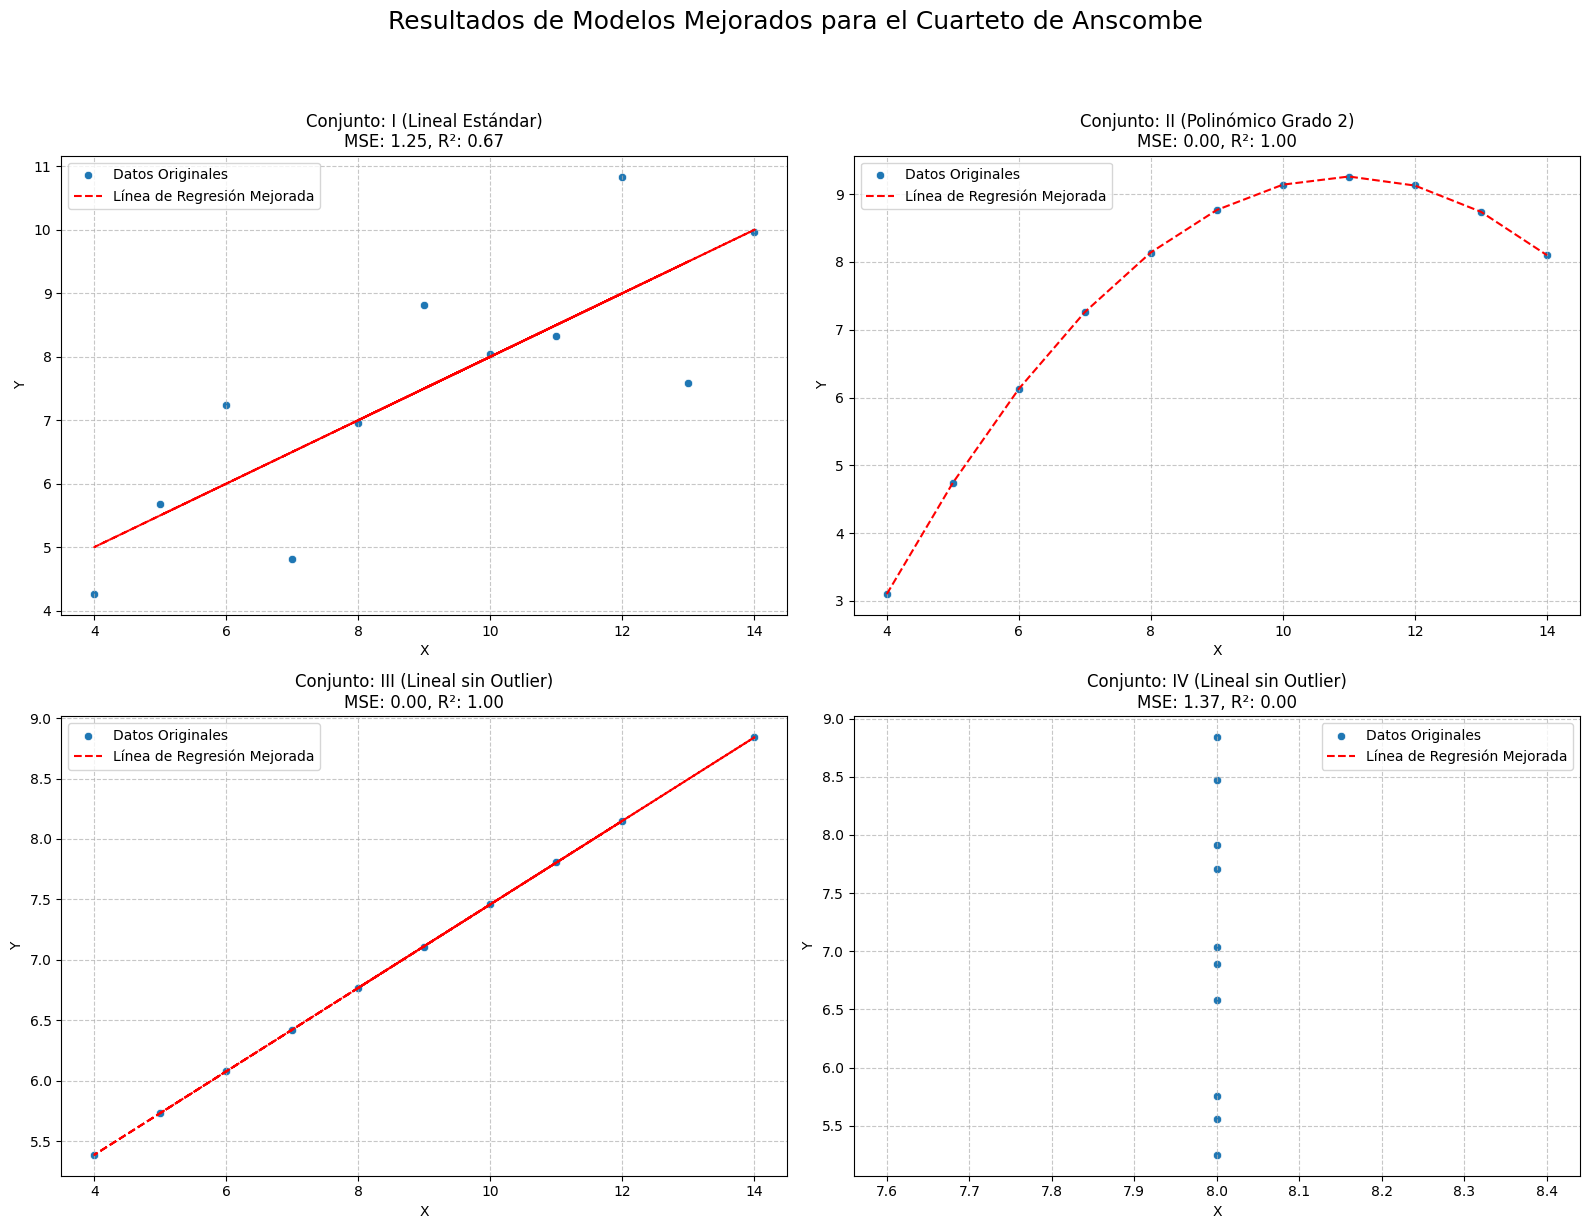

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('Modelos Mejorados y Alternativos para el Cuarteto de Anscombe:\n')

plt.figure(figsize=(16, 12))

# Obtener los datos sin el outlier para el Conjunto III y IV
data_no_outlier_III = data[(data['dataset'] == 'III') & (data['y'] < 12)]
data_no_outlier_IV = data[(data['dataset'] == 'IV') & (data['x'] < 19)]

# Mapear los datasets para procesarlos en el bucle
processed_datasets = {
    'I': {'data': data[data['dataset'] == 'I'], 'model_type': 'Linear'},
    'II': {'data': data[data['dataset'] == 'II'], 'model_type': 'Polynomial'},
    'III': {'data': data_no_outlier_III, 'model_type': 'Linear_No_Outlier'},
    'IV': {'data': data_no_outlier_IV, 'model_type': 'Linear_No_Outlier'}
}

for i, dataset_name in enumerate(processed_datasets.keys()):
    subset = processed_datasets[dataset_name]['data']
    model_type = processed_datasets[dataset_name]['model_type']

    X = subset[['x']]
    y = subset['y']

    if model_type == 'Polynomial':
        # Regresión polinómica de grado 2
        model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
        model.fit(X, y)
        y_pred = model.predict(X)
        title_suffix = ' (Polinómico Grado 2)'
    elif model_type == 'Linear_No_Outlier':
        # Regresión lineal sin outlier
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        title_suffix = ' (Lineal sin Outlier)'
    else:
        # Regresión lineal estándar para Conjunto I
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        title_suffix = ' (Lineal Estándar)'

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Imprimir resultados
    print(f'----- Conjunto de Datos: {dataset_name} ({model_type}) -----')
    # Print coefficients, handling for polynomial model
    if model_type == 'Polynomial':
        poly_features = model.named_steps['polynomialfeatures']
        linear_regression = model.named_steps['linearregression']
        print(f'Coeficientes (Polinómico): {linear_regression.coef_}')
        print(f'Intercepción: {linear_regression.intercept_:.3f}')
    else:
        print(f'Coeficiente (pendiente): {model.coef_[0]:.3f}')
        print(f'Intercepción: {model.intercept_:.3f}')
    print(f'Error Cuadrático Medio (MSE): {mse:.3f}')
    print(f'Coeficiente de Determinación (R²): {r2:.3f}')
    print('\n')

    # Graficar los resultados de la regresión
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x='x', y='y', data=subset, label='Datos Originales')

    # Plotting the regression line for polynomial model needs sorted X values
    if model_type == 'Polynomial':
        x_sorted = np.sort(X['x'].unique()).reshape(-1, 1)
        y_pred_sorted = model.predict(x_sorted)
        plt.plot(x_sorted, y_pred_sorted, color='red', linestyle='--', label='Línea de Regresión Mejorada')
    else:
        plt.plot(X, y_pred, color='red', linestyle='--', label='Línea de Regresión Mejorada')

    plt.title(f'Conjunto: {dataset_name}{title_suffix}\nMSE: {mse:.2f}, R²: {r2:.2f}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

plt.suptitle('Resultados de Modelos Mejorados para el Cuarteto de Anscombe', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [4]:
print('Estadísticas Descriptivas por Grupo para el Cuarteto de Anscombe:\n')
for dataset_name in data['dataset'].unique():
    subset = data[data['dataset'] == dataset_name]
    print(f'----- Conjunto de Datos: {dataset_name} -----')
    print(subset.describe())
    print('\n')

Estadísticas Descriptivas por Grupo para el Cuarteto de Anscombe:

----- Conjunto de Datos: I -----
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031568
min     4.000000   4.260000
25%     6.500000   6.315000
50%     9.000000   7.580000
75%    11.500000   8.570000
max    14.000000  10.840000


----- Conjunto de Datos: II -----
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031657
min     4.000000   3.100000
25%     6.500000   6.695000
50%     9.000000   8.140000
75%    11.500000   8.950000
max    14.000000   9.260000


----- Conjunto de Datos: III -----
               x          y
count  11.000000  11.000000
mean    9.000000   7.500000
std     3.316625   2.030424
min     4.000000   5.390000
25%     6.500000   6.250000
50%     9.000000   7.110000
75%    11.500000   7.980000
max    14.000000  12.740000


----- Conjunto de Datos: IV -----
               x          y
count  

### Análisis de las Estadísticas Descriptivas:

Como se anticipó en la introducción al Cuarteto de Anscombe y lo que visualizamos en los gráficos de dispersión, al observar las estadísticas descriptivas para cada uno de los cuatro conjuntos de datos, se confirman las similitudes sorprendentes a nivel numérico, a pesar de sus diferencias gráficas:

*   **Estadísticas de la variable `x`:**
    *   **Media:** Todos los conjuntos (I, II, III, IV) tienen una media de `x` muy cercana a `9.0` (todos son exactamente 9.0). Esto indica que, en promedio, los valores de la variable independiente son idénticos en todos los grupos.
    *   **Desviación Estándar (std):** La desviación estándar de `x` es idéntica en todos los grupos (alrededor de `3.16`). Esto sugiere que la dispersión de los valores de `x` alrededor de su media es la misma para los cuatro conjuntos.

*   **Estadísticas de la variable `y`:**
    *   **Media:** De manera similar, la media de `y` es muy consistente en todos los grupos, con valores muy cercanos a `7.5` (todos son exactamente 7.50). Esto significa que, en promedio, la variable dependiente también tiene el mismo valor medio en todos los conjuntos.
    *   **Desviación Estándar (std):** La desviación estándar de `y` también es prácticamente idéntica en todos los grupos (alrededor de `2.03`). Esto indica que la dispersión de los valores de `y` alrededor de su media es la misma para los cuatro conjuntos.

**Implicaciones de estas similitudes:**

Las estadísticas descriptivas (media, desviación estándar, min, max, cuartiles) de las variables `x` e `y` son prácticamente idénticas para los cuatro conjuntos de datos. Si nos basáramos únicamente en estos números, concluiríamos erróneamente que los conjuntos de datos son muy similares y que, por ejemplo, un modelo de regresión lineal funcionaría igualmente bien en todos ellos. Sin embargo, la visualización de los gráficos de dispersión nos ha mostrado patrones de relación completamente diferentes: lineal, curvilínea, lineal con outlier, y vertical con outlier.

Esta es la **principal lección del Cuarteto de Anscombe**: las estadísticas descriptivas por sí solas son insuficientes para comprender la verdadera naturaleza de los datos. La visualización de datos es una herramienta indispensable para identificar patrones, detectar valores atípicos y entender las relaciones subyacentes que los métodos puramente numéricos pueden ocultar.

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



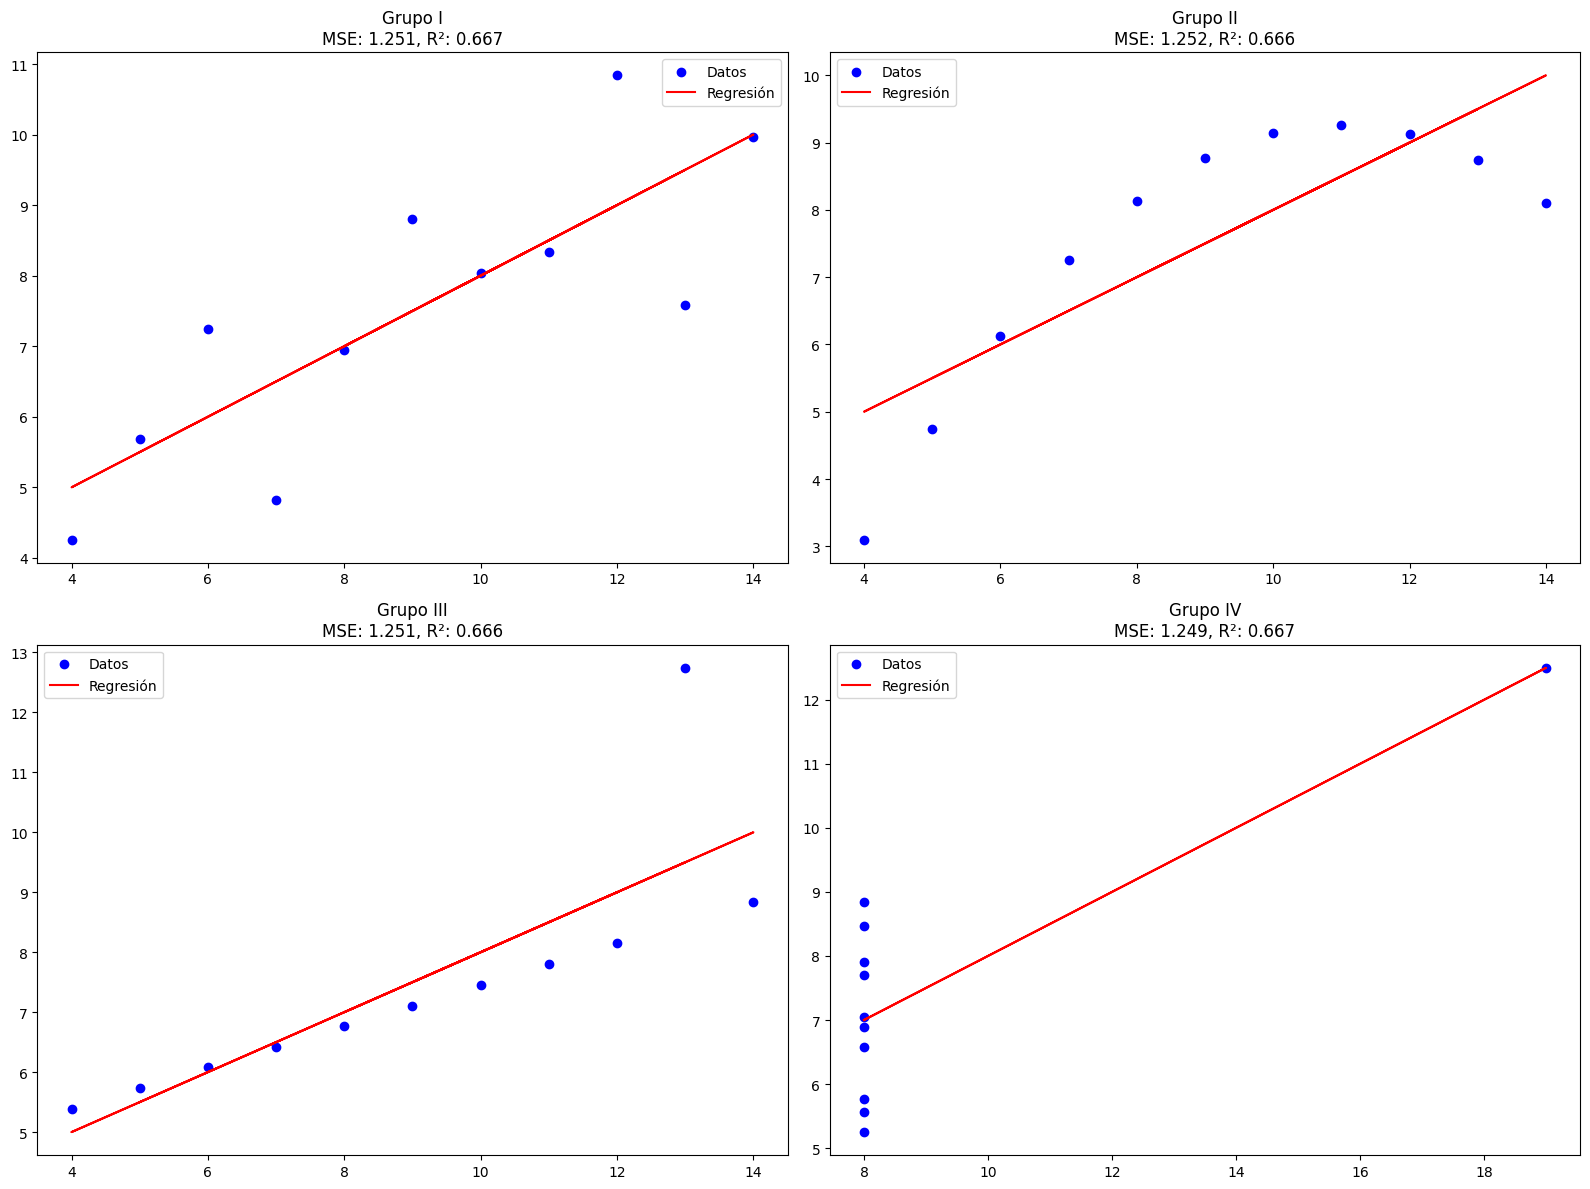

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Ajustar modelos de regresión lineal
plt.figure(figsize=(16, 12))

for i, dataset_name in enumerate(data['dataset'].unique()):
    subset = data[data['dataset'] == dataset_name]
    X = subset[['x']]
    y = subset['y']

    # Entrenar modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    y_pred = modelo.predict(X)

    # Calcular métricas
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Graficar
    plt.subplot(2, 2, i + 1)
    plt.scatter(X, y, color='blue', label='Datos')
    plt.plot(X, y_pred, color='red', label='Regresión')
    plt.title(f'Grupo {dataset_name}\nMSE: {mse:.3f}, R²: {r2:.3f}')
    plt.legend()

plt.tight_layout()
plt.show()

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/tmp/ipykernel_12749/3003542988.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


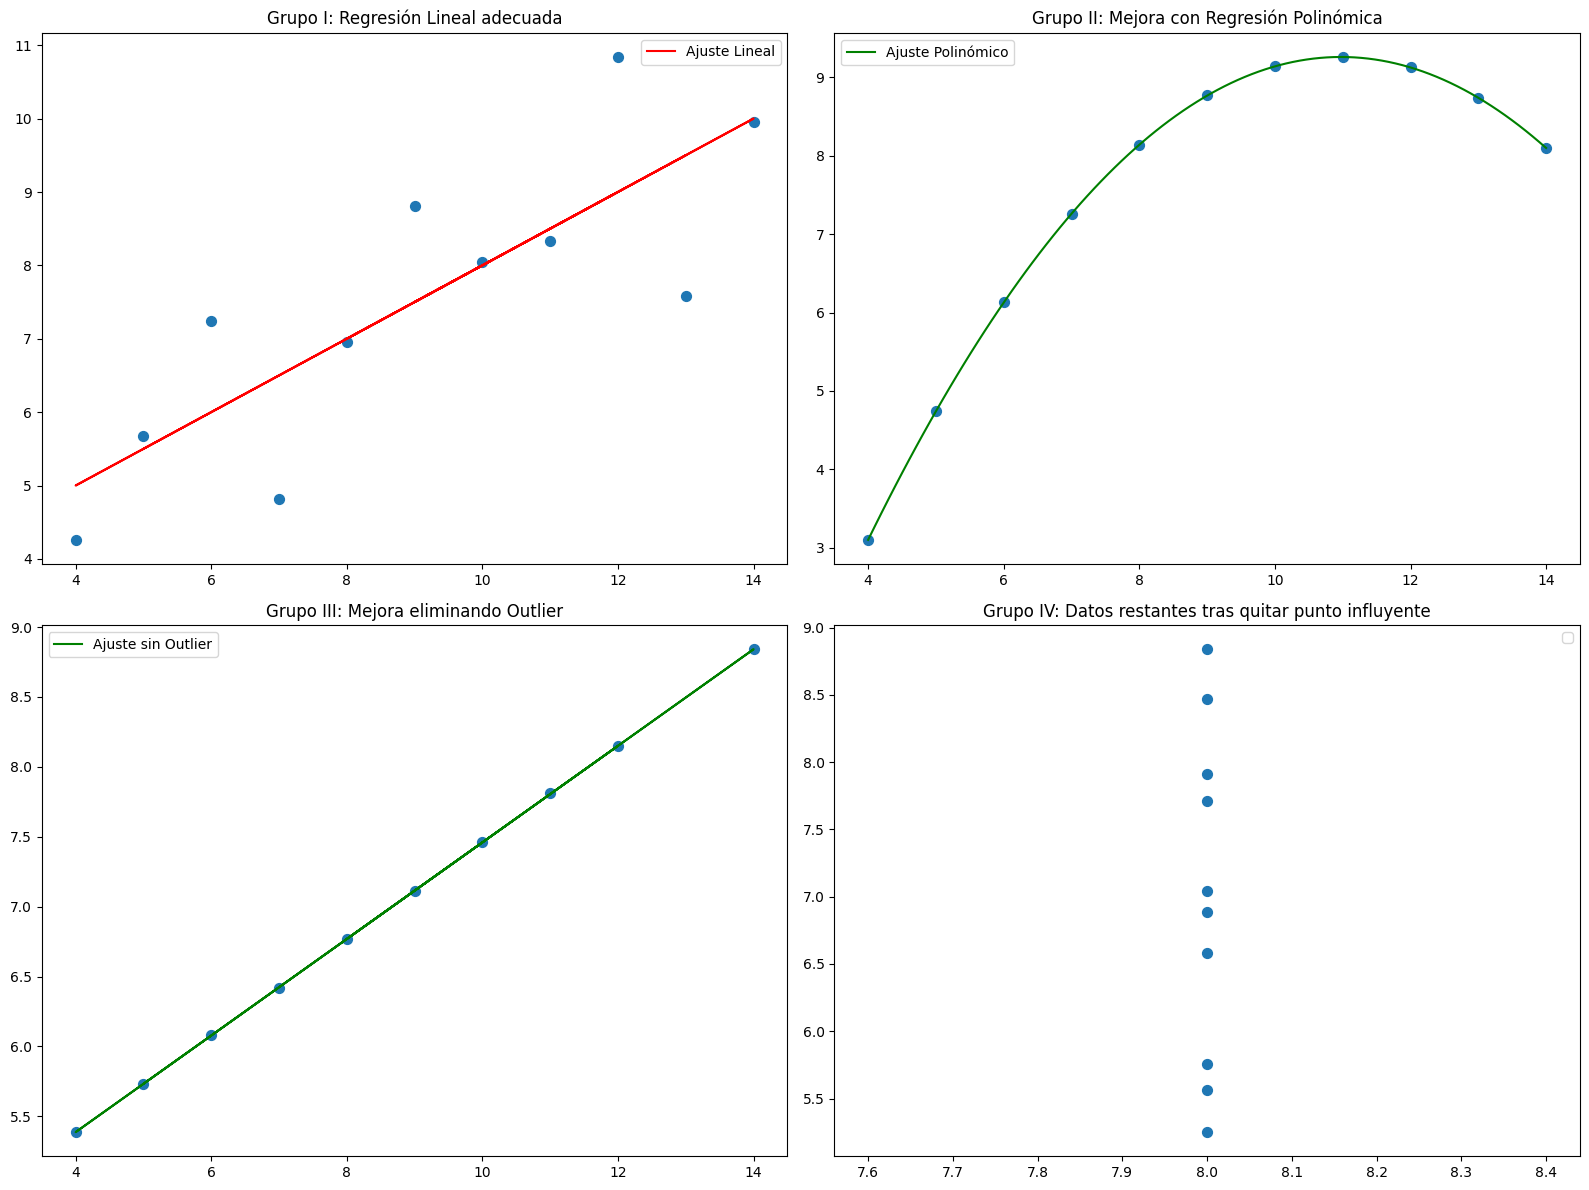

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import numpy as np

# Estrategias de mejora: Polinómica para II, Limpieza para III y IV
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, grupo in enumerate(['I', 'II', 'III', 'IV']):
    subset = data[data['dataset'] == grupo].copy()

    if grupo == 'II':
        # Regresión Polinómica Grado 2
        modelo = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
        X, y = subset[['x']], subset['y']
        modelo.fit(X, y)
        X_seq = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        y_pred = modelo.predict(X_seq)
        axes[i].plot(X_seq, y_pred, color='green', label='Ajuste Polinómico')
        axes[i].set_title('Grupo II: Mejora con Regresión Polinómica')

    elif grupo == 'III':
        # Eliminar el valor atípico
        subset = subset[subset['y'] < 12]
        modelo = LinearRegression()
        X, y = subset[['x']], subset['y']
        modelo.fit(X, y)
        axes[i].plot(X, modelo.predict(X), color='green', label='Ajuste sin Outlier')
        axes[i].set_title('Grupo III: Mejora eliminando Outlier')

    elif grupo == 'IV':
        # Eliminar el punto influyente
        subset = subset[subset['x'] < 15]
        axes[i].set_title('Grupo IV: Datos restantes tras quitar punto influyente')
        # (No se ajusta regresión útil aquí)

    else:
        # Grupo I queda igual
        modelo = LinearRegression()
        X, y = subset[['x']], subset['y']
        modelo.fit(X, y)
        axes[i].plot(X, modelo.predict(X), color='red', label='Ajuste Lineal')
        axes[i].set_title('Grupo I: Regresión Lineal adecuada')

    axes[i].scatter(subset['x'], subset['y'], s=50)
    axes[i].legend()

plt.tight_layout()
plt.show()